In [1]:
import pandas as pd
import yfinance as yfin
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
#nifty_50_stocks = ['BHARTIARTL.NS', 'LTIM.NS', 'HDFCLIFE.NS', 'NTPC.NS', 'MARUTI.NS','NESTLEIND.NS', 'BAJFINANCE.NS', 'KOTAKBANK.NS', 'TATASTEEL.NS',
#                   'ONGC.NS', 'BAJAJ-AUTO.NS', 'LT.NS', 'ITC.NS', 'TCS.NS', 'BRITANNIA.NS','SHRIRAMFIN.NS', 'ADANIENT.NS', 'CIPLA.NS', 'WIPRO.NS', 'INDUSINDBK.NS',
#                   'ULTRACEMCO.NS', 'TATACONSUM.NS', 'BAJAJFINSV.NS', 'RELIANCE.NS','HEROMOTOCO.NS', 'COALINDIA.NS', 'TITAN.NS', 'HINDALCO.NS',
#                   'APOLLOHOSP.NS']

Tickers = ['RELIANCE.NS', 'HDFCBANK.NS', 'TCS.NS', 'INFY.NS', 'ITC.NS', 'HEROMOTOCO.NS', 'COALINDIA.NS', 
           'TATASTEEL.NS', 'BRITANNIA.NS', 'APOLLOHOSP.NS']

start = dt.datetime.now().replace(year=dt.datetime.now().year - 1)
end = dt.datetime.now()

stocks = yfin.download(Tickers, start = start, end = end)
stocks

[*********************100%***********************]  10 of 10 completed


Price              Close                                                      \
Ticker     APOLLOHOSP.NS BRITANNIA.NS COALINDIA.NS HDFCBANK.NS HEROMOTOCO.NS   
Date                                                                           
2025-06-02   6897.502441  5532.496582   373.445007  953.166016   4089.546143   
2025-06-03   6794.770508  5503.377930   367.044952  949.466064   4066.645508   
2025-06-04   6837.159668  5470.311523   368.679993  957.655334   4058.915771   
2025-06-05   6858.104980  5527.561035   368.960266  961.799316   4037.947510   
2025-06-06   6924.432129  5534.963867   372.744263  976.155273   4124.041992   
...                  ...          ...          ...         ...           ...   
2026-05-26   8258.500000  5338.000000   458.149994  778.900024   4983.000000   
2026-05-27   8272.500000  5335.500000   463.049988  758.650024   5075.000000   
2026-05-28   8272.500000          NaN   463.049988  758.650024           NaN   
2026-05-29   8176.500000  5204.500000   457.899994  744.549988   4903.000000   
2026-06-01   8159.500000  5184.000000   473.100006  742.849976   4813.200195   

Price                                                                       \
Ticker          INFY.NS      ITC.NS  RELIANCE.NS TATASTEEL.NS       TCS.NS   
Date                                                                         
2025-06-02  1530.371826  399.800934  1408.076294   155.415619  3289.951904   
2025-06-03  1519.734619  397.560272  1399.908936   153.764145  3247.418213   
2025-06-04  1527.810913  397.607910  1417.837280   154.575211  3252.902588   
2025-06-05  1530.864258  399.610260  1436.662109   154.370010  3243.473633   
2025-06-06  1540.221069  401.469574  1437.757690   157.490005  3256.077637   
...                 ...         ...          ...          ...          ...   
2026-05-26  1167.699951  293.649994  1356.300049   210.470001  2276.199951   
2026-05-27  1159.900024  291.950012  1350.500000   214.699997  2284.199951   
2026-05-28  1159.900024  291.950012  1350.500000   214.699997  2284.199951   
2026-05-29  1160.900024  286.899994  1321.199951   208.020004  2258.899902   
2026-06-01  1207.199951  280.799988  1321.000000   210.380005  2305.800049   

Price       ...        Volume                                        \
Ticker      ... APOLLOHOSP.NS BRITANNIA.NS COALINDIA.NS HDFCBANK.NS   
Date        ...                                                       
2025-06-02  ...       1217905     625172.0      6119571    14668822   
2025-06-03  ...        489548     166545.0      7360608    24377584   
2025-06-04  ...        629518     334358.0      3861957    12961542   
2025-06-05  ...        488647     218004.0      6097293    22255418   
2025-06-06  ...        269399     152475.0      7633919    30127008   
...         ...           ...          ...          ...         ...   
2026-05-26  ...        310581     193734.0     17073323    31528062   
2026-05-27  ...        293786     195454.0    117042535    63680153   
2026-05-28  ...             0          NaN            0           0   
2026-05-29  ...       1042419    1697949.0     97895486   101299431   
2026-06-01  ...        164546     241865.0     43342638    20536619   

Price                                                                  \
Ticker     HEROMOTOCO.NS   INFY.NS    ITC.NS RELIANCE.NS TATASTEEL.NS   
Date                                                                    
2025-06-02      771163.0   4374509  14973380     8098668     31365564   
2025-06-03      417447.0   6853403  13216486    11252626     28398746   
2025-06-04      353642.0   4548307  12598933     8126827     16660138   
2025-06-05      394746.0   6948539  13212523    13716817     23708504   
2025-06-06      551467.0   3960020   8774988     8182161     25804151   
...                  ...       ...       ...         ...          ...   
2026-05-26      413024.0   8005767  37560542    13769747     17801824   
2026-05-27      460843.0   6371871  25446093    13215138     

In [3]:
stocks[('DailyReturns', 'REL')] = stocks[('Close', 'RELIANCE.NS')].pct_change(1) * 100
stocks[('DailyReturns', 'HDFC')] = stocks[('Close', 'HDFCBANK.NS')].pct_change(1) * 100
stocks[('DailyReturns', 'INF')] = stocks[('Close', 'INFY.NS')].pct_change(1) * 100
stocks[('DailyReturns', 'ITC')] = stocks[('Close', 'ITC.NS')].pct_change(1) * 100
stocks[('DailyReturns', 'TCS')] = stocks[('Close', 'TCS.NS')].pct_change(1) * 100
stocks[('DailyReturns', 'HERO')] = stocks[('Close', 'HEROMOTOCO.NS')].pct_change(1) * 100
stocks[('DailyReturns', 'COAL')] = stocks[('Close', 'COALINDIA.NS')].pct_change(1) * 100
stocks[('DailyReturns', 'TST')] = stocks[('Close', 'TATASTEEL.NS')].pct_change(1) * 100
stocks[('DailyReturns', 'BRIT')] = stocks[('Close', 'BRITANNIA.NS')].pct_change(1) * 100
stocks[('DailyReturns', 'APL')] = stocks[('Close', 'APOLLOHOSP.NS')].pct_change(1) * 100

In [4]:
stocks.replace(np.nan, 0, inplace = True)
dailyReturns = stocks.DailyReturns
dailyReturns

Ticker,REL,HDFC,INF,ITC,TCS,HERO,COAL,TST,BRIT,APL
Date,,,,,,,,,,
2025-06-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2025-06-03,-0.580037,-0.388175,-0.695073,-0.560444,-1.292836,-0.559980,-1.713788,-1.062618,-0.526320,-1.489408
2025-06-04,1.280679,0.862513,0.531428,0.011983,0.168884,-0.190076,0.445461,0.527474,-0.600838,0.623850
2025-06-05,1.327714,0.432722,0.199851,0.503599,-0.289863,-0.516598,0.076021,-0.132751,1.046549,0.306345
2025-06-06,0.076259,1.492615,0.611211,0.465282,0.388596,2.132135,1.025584,2.021115,0.133926,0.967135
...,...,...,...,...,...,...,...,...,...,...
2026-05-26,-0.782732,-1.010352,-0.068468,-0.756707,-1.386362,0.080337,0.032750,0.118923,0.206495,-1.731318
2026-05-27,-0.427638,-2.599820,-0.667974,-0.578914,0.351463,1.846277,1.069517,2.009786,-0.046834,0.169522
2026-05-28,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [5]:
scaler = StandardScaler()
scaledDailyReturns = scaler.fit_transform(dailyReturns)
scaledDailyReturns

array([[ 1.40628657e-02,  7.67803153e-02,  5.05855616e-02, ...,
        -8.05248057e-02,  1.42800589e-02, -6.01474653e-02],
       [-4.46812582e-01, -2.44515321e-01, -3.78113393e-01, ...,
        -7.09903563e-01, -4.01275955e-01, -1.25088640e+00],
       [ 1.03164285e+00,  7.90689761e-01,  3.78353247e-01, ...,
         2.31893121e-01, -4.60111676e-01,  4.38602609e-01],
       ...,
       [ 1.40628657e-02,  7.67803153e-02,  5.05855616e-02, ...,
        -8.05248057e-02,  1.42800589e-02, -6.01474653e-02],
       [-1.70979677e+00, -1.46157320e+00,  1.03759792e-01, ...,
        -1.92332797e+00, -1.92426378e+00, -9.87911241e-01],
       [ 2.03790823e-03, -1.12208265e-01,  2.51042782e+00, ...,
         5.91433021e-01, -2.96715583e-01, -2.26367908e-01]])

In [6]:
pca = PCA()
returnsPca = pca.fit_transform(scaledDailyReturns)

returnsPca

array([[-0.03923347, -0.08486814, -0.12468483, ..., -0.04874059,
         0.02608762, -0.04242739],
       [ 1.80425935,  0.23977737, -0.90059721, ..., -0.14128272,
         0.17255809,  0.14508057],
       [-0.93061968, -0.18920919,  0.31375643, ..., -0.55958297,
        -0.03695123,  0.11362958],
       ...,
       [-0.03923347, -0.08486814, -0.12468483, ..., -0.04874059,
         0.02608762, -0.04242739],
       [ 4.19175025, -1.54816825, -0.34923261, ..., -0.40061133,
         0.14615125,  0.26142747],
       [-0.65393218, -3.13476062,  2.34145953, ..., -1.11029418,
         0.08389984,  0.61165353]])

In [7]:
print(f"components: {pca.components_}" )
print(f"variances: {pca.explained_variance_}")
print(f"explanation variance ratios: {pca.explained_variance_ratio_}")
print(f"singular values: {pca.singular_values_}")
print(f"means: {pca.mean_}")

components: [[-0.34161898 -0.41075885 -0.26177715 -0.25421141 -0.33295411 -0.39769615
  -0.14620035 -0.33728022 -0.29136188 -0.30393751]
 [ 0.08548064  0.17007628 -0.66424783  0.16397895 -0.59748293  0.19045634
  -0.0249796   0.22803555  0.2117031   0.0703632 ]
 [ 0.11254627 -0.16011185 -0.08333614 -0.18804039 -0.00991483 -0.01204877
   0.78499773  0.40380454 -0.34126837 -0.15299123]
 [ 0.10963853  0.03611947 -0.0388114  -0.71744519 -0.06649163  0.18499669
  -0.18878365  0.02940936 -0.24047026  0.58091808]
 [-0.65008121 -0.1187733   0.05014849 -0.33309548  0.07859195  0.16391636
   0.07466947  0.2968295   0.56290816 -0.07890309]
 [-0.26941097 -0.09522401 -0.07899661  0.27435865 -0.00433112 -0.31180477
   0.40867313 -0.28930198  0.12435108  0.68805774]
 [-0.57108971  0.19735011  0.00314036  0.32357841  0.0421476   0.25232584
  -0.16686496  0.25193845 -0.60225911  0.10353232]
 [ 0.08744119 -0.70229913 -0.02978479  0.1903051   0.03151535  0.64596753
   0.00663524 -0.19822371 -0.01161578  

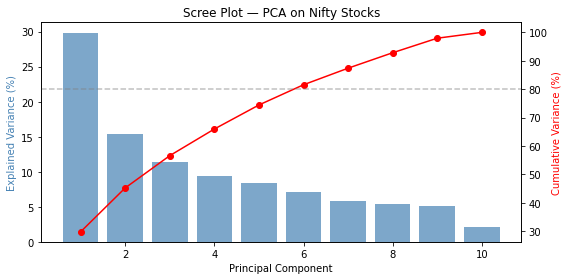

In [8]:
explained = pca.explained_variance_ratio_ * 100
cumulative = np.cumsum(explained)

fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.bar(range(1, len(explained)+1), explained, color='steelblue', alpha=0.7, label='Individual')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance (%)', color='steelblue')

ax2 = ax1.twinx()
ax2.plot(range(1, len(cumulative)+1), cumulative, 'ro-', label='Cumulative')
ax2.set_ylabel('Cumulative Variance (%)', color='red')
ax2.axhline(y=80, color='gray', linestyle='--', alpha=0.5, label='80% threshold')

plt.title('Scree Plot — PCA on Nifty Stocks')
fig.tight_layout()
plt.show()

In [9]:
# How many principal components are needed to explain >=80 % of variance?
cumulative_var = np.cumsum(pca.explained_variance_ratio_)
for i, cv in enumerate(cumulative_var):
    if cv >= 0.80:
        print(f"{i+1} components explain {cv*100:.1f}% of variance (>=80% threshold)")
        break

print("\nCumulative variance explained:")
for i, cv in enumerate(cumulative_var):
    print(f"  PC{i+1}: {cv*100:.1f}%")

6 components explain 81.6% of variance (>=80% threshold)

Cumulative variance explained:
  PC1: 29.8%
  PC2: 45.3%
  PC3: 56.6%
  PC4: 66.0%
  PC5: 74.5%
  PC6: 81.6%
  PC7: 87.4%
  PC8: 92.8%
  PC9: 97.9%
  PC10: 100.0%


## PC1 is the Market Factor
Notice that **PC1 has all negative loadings** across every stock.
This is the classic *market factor* — it captures the direction in which **all stocks move together**.
PC2 and beyond capture sector-specific or stock-specific variation.

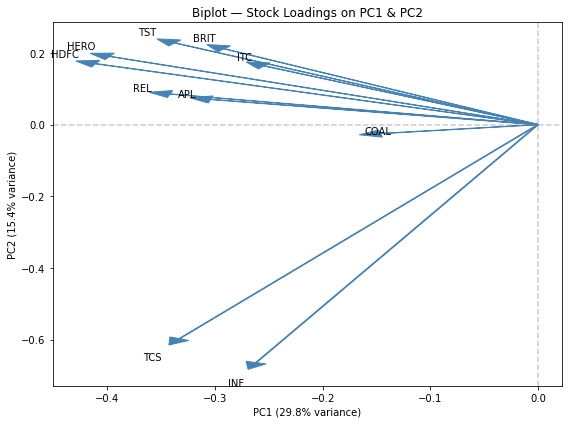

In [10]:
stock_names = ['REL', 'HDFC', 'INF', 'ITC', 'TCS', 'HERO', 'COAL', 'TST', 'BRIT', 'APL']
loadings = pca.components_.T   # shape: (10 stocks, 10 PCs)

fig, ax = plt.subplots(figsize=(8, 6))

# Plot loading arrows for each stock
for i, name in enumerate(stock_names):
    ax.arrow(0, 0, loadings[i, 0], loadings[i, 1],
             head_width=0.02, head_length=0.02, fc='steelblue', ec='steelblue')
    ax.text(loadings[i, 0] * 1.1, loadings[i, 1] * 1.1, name, fontsize=10)

ax.axhline(0, color='gray', linestyle='--', alpha=0.4)
ax.axvline(0, color='gray', linestyle='--', alpha=0.4)
ax.set_xlabel(f'PC1 ({explained[0]:.1f}% variance)')
ax.set_ylabel(f'PC2 ({explained[1]:.1f}% variance)')
ax.set_title('Biplot — Stock Loadings on PC1 & PC2')
plt.tight_layout()
plt.show()

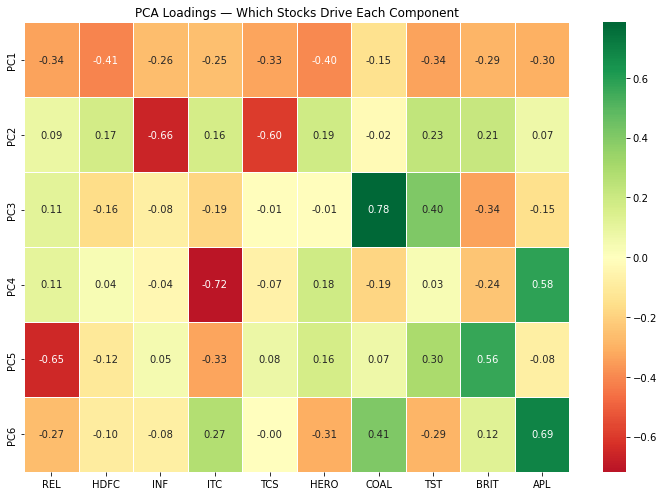

In [11]:
loadings_df = pd.DataFrame(
    pca.components_,
    columns=stock_names,
    index=[f'PC{i+1}' for i in range(len(stock_names))]
)

plt.figure(figsize=(10, 7))
sns.heatmap(loadings_df.iloc[:6],   # first 5 PCs is enough
            annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            linewidths=0.5)
plt.title('PCA Loadings — Which Stocks Drive Each Component')
plt.tight_layout()
plt.show()